In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
from datetime import datetime
from tqdm.auto import tqdm
import sys
sys.path.append("/root/autodl-tmp/jump")
from scripts.build_final_features import FINAL_FEATURES
from jump_dl.src.dataio import build_slice_dataloader

In [2]:
df = pl.read_parquet("../data/data.parquet")

In [4]:
target = df.select(["Time", "Symbol", "ret_5min"])

In [10]:
for t in [5, 10, 15, 20, 25]:
    df = df.join(
        target.select([f"{t}min_ago", "Symbol", "ret_5min"]).rename({f"{t}min_ago": "Time", "ret_5min": f"ret_{t}_{t+5}min"}), 
        on=["Time", "Symbol"], 
        how="left"
    )
    print(t, "done")

5 done
10 done
15 done
20 done
25 done


In [14]:
df.write_parquet("../data/data.parquet")

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_corr_heatmap(corr, title="Symbol-wise correlation"):
    # corr: pd.DataFrame, shape = (n_symbols, n_symbols)

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(
        corr.values,
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
        aspect="auto",
    )

    ax.set_title(title)
    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("corr")

    plt.tight_layout()
    plt.show()

In [35]:
import numpy as np
import pandas as pd

from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import squareform


def corr_to_distance(corr: pd.DataFrame, mode: str = "signed"):
    """
    mode:
      - signed: corr 越高越近，负相关越远
      - abs: abs(corr) 越高越近，不管正负
    """

    C = corr.copy().astype(float)

    # 保证 index / columns 一致
    common = C.index.intersection(C.columns)
    C = C.loc[common, common]

    # 显式复制成 writable ndarray
    C_np = C.to_numpy(copy=True)

    # 处理 NaN / inf / 数值误差
    C_np = np.nan_to_num(C_np, nan=0.0, posinf=0.0, neginf=0.0)
    C_np = np.clip(C_np, -1.0, 1.0)

    # 强制对称化，避免数值误差
    C_np = 0.5 * (C_np + C_np.T)

    np.fill_diagonal(C_np, 1.0)

    if mode == "signed":
        # correlation distance
        D = np.sqrt(np.maximum(0.0, 0.5 * (1.0 - C_np)))
    elif mode == "abs":
        D = np.sqrt(np.maximum(0.0, 1.0 - np.abs(C_np)))
    else:
        raise ValueError("mode must be 'signed' or 'abs'")

    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)

    return pd.DataFrame(D, index=common, columns=common)


def cluster_corr(corr: pd.DataFrame, mode: str = "signed", method: str = "average"):
    dist = corr_to_distance(corr, mode=mode)

    condensed = squareform(dist.to_numpy(copy=True), checks=False)

    Z = linkage(
        condensed,
        method=method,
        optimal_ordering=True,
    )

    order = leaves_list(Z)
    symbols_ordered = dist.index[order].tolist()

    corr_clean = corr.loc[symbols_ordered, symbols_ordered]
    corr_ordered = corr_clean.astype(float)

    return corr_ordered, Z, symbols_ordered

In [63]:
import numpy as np
import polars as pl


def pairwise_corr_nan(
    Y: np.ndarray,
    X: np.ndarray,
    min_obs: int = 30,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Compute pairwise correlation between columns of Y and columns of X.

    Returns:
        C[i, j] = corr(Y[:, i], X[:, j])

    Correctly handles NaN pairwise:
        each C[i, j] only uses rows where both Y[:, i] and X[:, j] are finite.
    """
    Y = np.asarray(Y, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)

    if Y.ndim != 2 or X.ndim != 2:
        raise ValueError("Y and X must both be 2D arrays.")

    if Y.shape[0] != X.shape[0]:
        raise ValueError(f"Y and X must have same number of rows, got {Y.shape[0]} and {X.shape[0]}.")

    valid_y = np.isfinite(Y)
    valid_x = np.isfinite(X)

    # Important: cast mask to float, otherwise mask.T @ mask may not give integer counts correctly.
    My = valid_y.astype(np.float64)
    Mx = valid_x.astype(np.float64)

    Y0 = np.where(valid_y, Y, 0.0)
    X0 = np.where(valid_x, X, 0.0)

    # n[i, j] = number of rows where both Y[:, i] and X[:, j] are finite
    n = My.T @ Mx  # shape: Ny x Nx

    # Pairwise sums
    sum_y = Y0.T @ Mx        # sum of Y_i over rows where X_j valid too
    sum_x = My.T @ X0        # sum of X_j over rows where Y_i valid too
    sum_yx = Y0.T @ X0       # sum of Y_i * X_j over pairwise valid rows

    sum_yy = (Y0 * Y0).T @ Mx
    sum_xx = My.T @ (X0 * X0)

    with np.errstate(divide="ignore", invalid="ignore"):
        # unnormalized covariance / variance terms
        cov = sum_yx - (sum_y * sum_x) / n
        var_y = sum_yy - (sum_y * sum_y) / n
        var_x = sum_xx - (sum_x * sum_x) / n

        denom = np.sqrt(var_y * var_x)
        corr = cov / denom

    bad = (
        (n < min_obs)
        | (~np.isfinite(corr))
        | (var_y <= eps)
        | (var_x <= eps)
        | (denom <= eps)
    )

    corr[bad] = np.nan

    # Numerical safety
    corr = np.clip(corr, -1.0, 1.0)

    return corr

def lead_lag_corr_from_wide(
    wide: pl.DataFrame,
    lag: int,
    symbols=None,
    min_obs: int = 30,
) -> tuple[np.ndarray, list[str]]:
    """
    Compute lead-lag correlation matrix.

    Convention:
        C[i, j] = corr(ret_i(t), ret_j(t - lag))

    Interpretation:
        column j is the leader
        row i is the follower

    So if C[i, j] is large:
        symbol j leads symbol i by `lag` bars.
    """
    if lag < 0:
        raise ValueError("lag must be non-negative.")

    if symbols is None:
        symbols = [c for c in wide.columns if c not in ("Time", "date")]

    wide = wide.sort("Time")

    X_all = wide.select(symbols).to_numpy().astype(np.float64)  # T x N

    if lag == 0:
        Y = X_all
        X_lag = X_all
    else:
        if X_all.shape[0] <= lag:
            raise ValueError(f"Not enough rows: T={X_all.shape[0]}, lag={lag}.")

        # target at current time
        Y = X_all[lag:, :]

        # leader at lagged time
        X_lag = X_all[:-lag, :]

    C = pairwise_corr_nan(Y, X_lag, min_obs=min_obs)

    return C, symbols

def top_lead_lag_edges(
    C: np.ndarray,
    symbols: list[str],
    top_n: int = 50,
    min_abs_corr: float = 0.0,
) -> pl.DataFrame:
    rows = []
    N = len(symbols)

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            cij = C[i, j]
            if not np.isfinite(cij):
                continue
            if abs(cij) < min_abs_corr:
                continue

            cji = C[j, i]
            asym = cij - cji if np.isfinite(cji) else np.nan

            rows.append({
                "leader": symbols[j],
                "follower": symbols[i],
                "corr_leader_to_follower": float(cij),
                "reverse_corr": float(cji) if np.isfinite(cji) else None,
                "asym_score": float(asym) if np.isfinite(asym) else None,
                "abs_asym_score": float(abs(asym)) if np.isfinite(asym) else None,
            })

    if len(rows) == 0:
        return pl.DataFrame({
            "leader": [],
            "follower": [],
            "corr_leader_to_follower": [],
            "reverse_corr": [],
            "asym_score": [],
            "abs_asym_score": [],
        })

    return (
        pl.DataFrame(rows)
        .sort("abs_asym_score", descending=True)
        .head(top_n)
    )

In [82]:
C30_new, symbols = lead_lag_corr_from_wide(cdfs[45], lag=30)

In [66]:
C5, symbols = lead_lag_corr_from_wide(all_corr, lag=5)

In [71]:
def best_lag_edges(
    lag_corrs: dict[int, np.ndarray],
    symbols: list[str],
    top_n: int = 100,
) -> pl.DataFrame:
    rows = []
    lags = sorted(lag_corrs.keys())
    N = len(symbols)

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            vals = np.array([lag_corrs[lag][i, j] for lag in lags], dtype=np.float64)
            revs = np.array([lag_corrs[lag][j, i] for lag in lags], dtype=np.float64)

            if np.all(~np.isfinite(vals)):
                continue

            asym = vals - revs

            if np.all(~np.isfinite(asym)):
                continue

            idx = np.nanargmax(np.abs(asym))

            rows.append({
                "leader": symbols[j],
                "follower": symbols[i],
                "best_lag": lags[idx],
                "corr": float(vals[idx]) if np.isfinite(vals[idx]) else None,
                "reverse_corr": float(revs[idx]) if np.isfinite(revs[idx]) else None,
                "asym_score": float(asym[idx]) if np.isfinite(asym[idx]) else None,
                "abs_asym_score": float(abs(asym[idx])) if np.isfinite(asym[idx]) else None,
            })

    return (
        pl.DataFrame(rows)
        .sort("abs_asym_score", descending=True)
        .head(top_n)
    )

In [73]:
best_edges = best_lag_edges(lag_corrs, symbols, top_n=100)
best_edges

leader,follower,best_lag,corr,reverse_corr,asym_score,abs_asym_score
str,str,i64,f64,f64,f64,f64
"""SN""","""EB""",45,0.108187,-0.074752,0.18294,0.18294
"""EB""","""SN""",45,-0.074752,0.108187,-0.18294,0.18294
"""RR""","""NR""",15,0.015203,0.158571,-0.143369,0.143369
"""NR""","""RR""",15,0.158571,0.015203,0.143369,0.143369
"""SF""","""EB""",45,0.026716,-0.108732,0.135449,0.135449
…,…,…,…,…,…,…
"""PP""","""UR""",20,0.115854,0.036545,0.079309,0.079309
"""NR""","""AU""",45,0.064642,-0.014498,0.07914,0.07914
"""AU""","""NR""",45,-0.014498,0.064642,-0.07914,0.07914


In [72]:
lags = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60]

lag_corrs = {}

wide = all_corr

for lag in lags:
    C, symbols = lead_lag_corr_from_wide(
        wide,
        lag=lag,
        min_obs=30,
    )
    lag_corrs[lag] = C

    print(
        lag,
        "finite ratio:",
        np.isfinite(C).mean(),
        "median abs corr:",
        np.nanmedian(np.abs(C)),
    )

1 finite ratio: 1.0 median abs corr: 0.18409594479394964
2 finite ratio: 1.0 median abs corr: 0.1790658418644837
3 finite ratio: 1.0 median abs corr: 0.1737298482591381
5 finite ratio: 1.0 median abs corr: 0.16181339306715672
10 finite ratio: 1.0 median abs corr: 0.13152340000492233
15 finite ratio: 1.0 median abs corr: 0.1025077988861173
20 finite ratio: 1.0 median abs corr: 0.0709406622253489
30 finite ratio: 1.0 median abs corr: 0.014983997719319278
45 finite ratio: 1.0 median abs corr: 0.01217353152948214
60 finite ratio: 1.0 median abs corr: 0.0104447853747416


In [3]:
cdf = df.with_columns([
    pl.col("Time").dt.date().alias("date")
])

In [54]:
all_corr = cdf.pivot(
    index="Time",
    on="Symbol",
    values="ret_30min",
).sort("Time")

In [36]:
corr_ordered, Z, symbols_ordered = cluster_corr(
    all_corr,
    mode="signed",
    method="average",
)

In [4]:
cdfs = cdf.pivot(
    index="Time",
    on="Symbol",
    values="ret_30min",
).with_columns([c
    pl.col("Time").dt.date().alias("date")
]).partition_by("date")

In [43]:
for i, sub_df in enumerate(cdfs):
    corr_old = None if i == 0 else corr
    corr = sub_df.drop(["Time", "date"]).to_pandas().corr()
    if i > 300:
        break

In [41]:
def get_cluster_labels(corr, Z, n_clusters=6):
    labels = fcluster(Z, t=n_clusters, criterion="maxclust")

    cluster_df = pd.DataFrame({
        "symbol": corr.index,
        "cluster": labels,
    }).sort_values(["cluster", "symbol"])

    return cluster_df


cluster_df = get_cluster_labels(all_corr, Z, n_clusters=13)
print(cluster_df)

   symbol  cluster
7       C        1
10     CS        1
0       A        2
5       B        2
24      M        2
28     OI        2
29      P        2
33     RM        2
47      Y        2
42     SR        3
21     JD        4
8      CF        5
12     CY        5
2      AL        6
6      BU        6
11     CU        6
13     EB        6
14     EG        6
16     FG        6
17     FU        6
18     HC        6
19      I        6
20      J        6
22     JM        6
23      L        6
25     MA        6
26     NI        6
27     NR        6
30     PB        6
31     PP        6
32     RB        6
35     RU        6
36     SA        6
37     SC        6
40     SN        6
43     SS        6
44     TA        6
46      V        6
48     ZC        6
49     ZN        6
38     SF        7
39     SM        7
41     SP        8
45     UR        9
3      AP       10
9      CJ       10
34     RR       11
1      AG       12
4      AU       12
15     FB       13


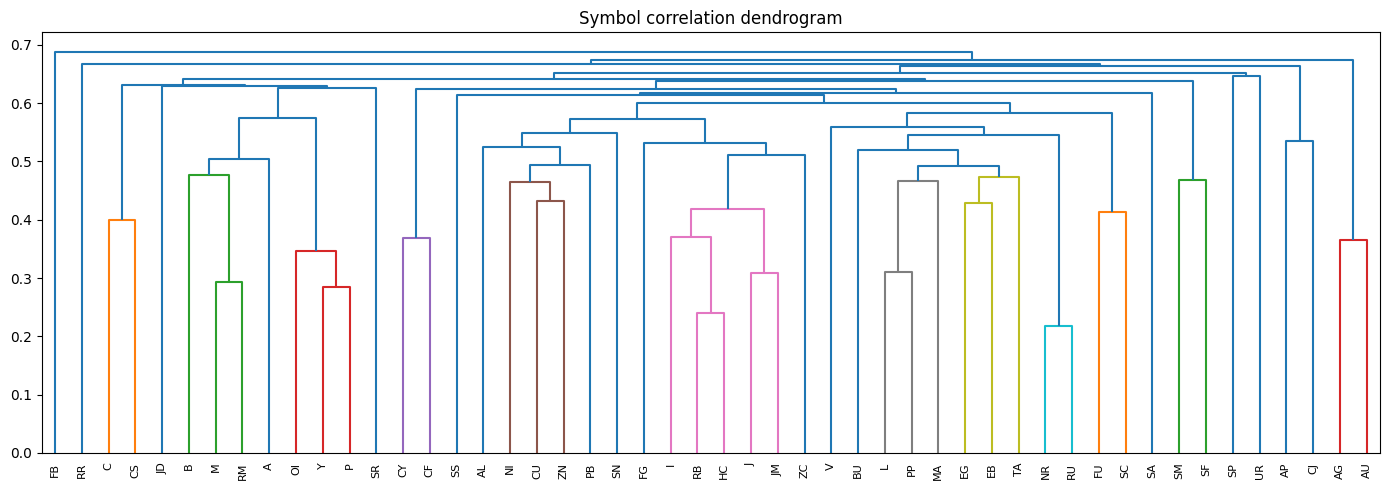

In [42]:
plt.figure(figsize=(14, 5))
dendrogram(
    Z,
    labels=all_corr.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.title("Symbol correlation dendrogram")
plt.tight_layout()
plt.show()